# K-mer MLP for Full GO Prediction

## Project goal
We train a multi-label MLP model to predict Gene Ontology (GO) terms from k-mer frequency features extracted from protein sequences.

This experiment uses the **full GO label space**.  
The goal is to build a complete baseline that reflects the real difficulty of CAFA-style protein function prediction:
- high-dimensional output space
- severe class imbalance
- extremely sparse labels
- multi-label prediction for each protein

## Why this notebook matters
Our data preparation pipeline already produced:
- cleaned and aligned protein samples
- normalized k-mer feature vectors
- train/validation splits
- multi-label GO targets stored as sparse matrices

This begins at the **model construction stage**, using the processed k-mer outputs as direct inputs for supervised learning.

## Input / output summary
- **Input features:** normalized 2-mer frequency vectors, dimension = 400
- **Output labels:** all GO terms, dimension = 31,454
- **Task type:** multi-label classification
- **Evaluation:** validation loss and threshold-based F1 analysis

## Step 0. Imports

In [1]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import load_npz

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score

## Step 1. Load Processed K-mer Training Data

### Why this step?
The k-mer preprocessing notebook already converted raw protein sequences into standardized 2-mer frequency vectors and saved the aligned GO labels.

Loading these processed files allows us to begin model training directly, without repeating:
- sequence cleaning
- GO label alignment
- k-mer vectorization
- train/validation splitting
- feature standardization

### Files loaded
We load:
- `X_train.npy` and `X_val.npy`: standardized k-mer feature matrices
- `Y_train.npz` and `Y_val.npz`: sparse multi-label GO target matrices
- `train_idx.npy` and `val_idx.npy`: split indices
- `meta.pkl`: metadata including vocabulary, scaler, protein IDs, and GO encoder

### Why sparse labels matter
The target matrix contains all GO terms, so the label space is very large and mostly zeros.  
Keeping the targets in sparse form helps avoid unnecessary memory use.

In [2]:
DATA_DIR = "data_processed_kmer"

X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))

Y_train = load_npz(os.path.join(DATA_DIR, "Y_train.npz"))
Y_val   = load_npz(os.path.join(DATA_DIR, "Y_val.npz"))

train_idx = np.load(os.path.join(DATA_DIR, "train_idx.npy"))
val_idx   = np.load(os.path.join(DATA_DIR, "val_idx.npy"))

with open(os.path.join(DATA_DIR, "meta.pkl"), "rb") as f:
    meta = pickle.load(f)

print("X_train:", X_train.shape, X_train.dtype)
print("X_val:  ", X_val.shape, X_val.dtype)
print("Y_train:", Y_train.shape, type(Y_train))
print("Y_val:  ", Y_val.shape, type(Y_val))
print("train_idx:", train_idx.shape)
print("val_idx:  ", val_idx.shape)
print("meta keys:", list(meta.keys()))

X_train: (112455, 400) float32
X_val:   (28114, 400) float32
Y_train: (112455, 31454) <class 'scipy.sparse._csr.csr_matrix'>
Y_val:   (28114, 31454) <class 'scipy.sparse._csr.csr_matrix'>
train_idx: (112455,)
val_idx:   (28114,)
meta keys: ['protein_ids', 'go_terms']


## Step 2. Sanity Check of Input and Output Dimensions

### Why this step?
Before defining the model, we verify that:
1. the input dimension matches the expected k-mer representation
2. the output dimension matches the full GO label space
3. the metadata is aligned with the loaded arrays

This step helps catch common issues early, such as:
- mismatched feature files
- wrong metadata version
- incorrect GO encoder loading
- accidental use of filtered labels instead of full labels

### Expected dimensions
From the data preparation notebook, the k-mer feature dimension should be **400**, and the full GO output dimension should be **31,454**. This matches the CAFA5 preprocessing summary.

In [3]:
print("Input dim (k-mer):", X_train.shape[1])
print("Output dim (all GO terms):", Y_train.shape[1])

if "mlb" in meta:
    mlb = meta["mlb"]
    print("Number of GO classes from mlb:", len(mlb.classes_))
    print("First 10 GO terms:", mlb.classes_[:10])

if "protein_ids" in meta:
    protein_ids = meta["protein_ids"]
    print("Number of protein_ids:", len(protein_ids))

Input dim (k-mer): 400
Output dim (all GO terms): 31454
Number of protein_ids: 140569


## Step 3. Build a Sparse-Safe PyTorch Dataset

### Why this step?
PyTorch models expect mini-batches of tensors, but our GO label matrix is stored as a sparse matrix to save memory.

If we convert the full target matrix into a dense array all at once, memory usage can become unnecessarily large because:
- the number of proteins is large
- the GO label space contains over 31,000 classes
- the label matrix is extremely sparse

### Design choice
We therefore define a custom dataset that:
- reads dense k-mer features from NumPy arrays
- converts only one sparse label row at a time into a dense tensor
- returns `(x, y)` pairs ready for mini-batch training

### Why this is important
This lets us train on the **full GO label space** without filtering labels and without densifying the entire target matrix in memory.

In [4]:
class ProteinKmerDataset(Dataset):
    def __init__(self, X, Y_sparse):
        self.X = X
        self.Y = Y_sparse

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx].toarray().ravel(), dtype=torch.float32)
        return x, y

## Step 4. Create DataLoaders for Mini-Batch Training

### Why this step?
DataLoaders provide efficient mini-batch iteration during training and validation.

We use them to:
- shuffle training samples each epoch
- batch proteins into manageable groups
- keep validation order fixed
- optionally use pinned memory for faster GPU transfer

### Why batch size is kept moderate
Even though the input dimension is small (400), the output dimension is very large (31,454).  
This means each forward/backward pass still produces large output tensors, so a moderate batch size is safer for memory and runtime stability.

In [5]:
train_dataset = ProteinKmerDataset(X_train, Y_train)
val_dataset   = ProteinKmerDataset(X_val, Y_val)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))

Train batches: 1758
Val batches:   440


/global/home/users/yushanfu/esm_env/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12030). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Step 5. Define the K-mer MLP Model

### Why this step?
The model maps each protein's k-mer frequency vector to a multi-label GO prediction vector.

Because the input features are fixed-length tabular vectors, a multilayer perceptron (MLP) is a natural baseline:
- simple to implement
- efficient to train
- appropriate for dense handcrafted features like k-mer frequencies

### Model structure
The architecture uses:
- two hidden layers
- batch normalization for optimization stability
- ReLU nonlinearities
- dropout for regularization

### Why an MLP is a reasonable baseline
The k-mer representation captures local amino acid composition but not full sequence context.  
An MLP provides a clean baseline for testing how much predictive signal exists in these handcrafted sequence features before moving to richer representations such as ESM embeddings or structural graphs. This is consistent with the role of k-mer features in your preprocessing notebook, where they are described as a fast and interpretable baseline.

In [6]:
class KmerMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden1=512, hidden2=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.net(x)

## Step 6. Initialize the Model on the Available Device

Here we:
- detect whether a GPU is available
- construct the model using the correct input and output dimensions
- move the model to the computation device
- inspect the total number of trainable parameters

### Why parameter count matters
The input dimension is modest, but the output layer is large because the model predicts all GO terms at once.  
Printing the parameter count helps us understand the memory and optimization cost of training on the full label space.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = KmerMLP(
    input_dim=X_train.shape[1],   # 400
    output_dim=Y_train.shape[1]   # 31454
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", f"{n_params:,}")
print(model)

Device: cpu
Total parameters: 8,421,854
KmerMLP(
  (net): Sequential(
    (0): Linear(in_features=400, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=31454, bias=True)
  )
)


## Step 7. Compute Class Weights for Extreme Label Imbalance

### Why this step?
GO prediction is an extremely imbalanced multi-label problem.

In the preprocessing analysis, the label matrix was shown to be highly sparse, with most entries equal to zero and many GO terms appearing only rarely. The long-tail frequency pattern is one of the main challenges of this task. 

If we train with an unweighted binary loss, the model can minimize loss by predicting negatives for most labels.  
This would lead to poor learning for rare positive GO terms.

### What we do
We compute a `pos_weight` value for each GO term:
- rare labels receive higher positive weight
- common labels receive lower positive weight

### Why BCEWithLogitsLoss + pos_weight
This is the standard choice for multi-label classification when:
- each output is an independent binary target
- the label distribution is heavily imbalanced
- we want the model to pay more attention to rare positive examples

In [8]:
label_counts = np.asarray(Y_train.sum(axis=0)).ravel().astype(np.float32)
n_train = Y_train.shape[0]

# Compute positive class weights for each GO term.
# Rare labels receive larger weights, while common labels receive smaller weights.
# Add a small epsilon to avoid division by zero for labels with no positive samples.
pos_weight = (n_train - label_counts) / (label_counts + 1e-6)

# Clip extreme values to keep training numerically stable.
# Without clipping, very rare labels can produce huge weights and explode the loss.
pos_weight = np.clip(pos_weight, 1.0, 100.0)

print("label_counts shape:", label_counts.shape)
print("pos_weight shape:", pos_weight.shape)
print("label count min/max:", label_counts.min(), label_counts.max())
print("pos_weight min/max:", pos_weight.min(), pos_weight.max())

# Convert to a PyTorch tensor on the same device as the model.
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32, device=device)

# Use weighted binary cross-entropy for multi-label classification.
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# Adam optimizer with light L2 regularization.
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

label_counts shape: (31454,)
pos_weight shape: (31454,)
label count min/max: 0.0 73516.0
pos_weight min/max: 1.0 100.0


## Step 8. Define Training and Validation Loops

### Why this step?
To train the model reproducibly, we separate the workflow into two functions:
- `train_one_epoch(...)` for parameter updates
- `evaluate_loss(...)` for validation without gradient computation

### Why this separation helps
This makes the notebook easier to:
- debug
- reuse for ESM features later
- compare training vs validation behavior
- save the best model based on validation performance

### What happens during training
For each batch:
1. move inputs and targets to the device
2. compute logits
3. compute the weighted multi-label loss
4. backpropagate gradients
5. update model parameters

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        Y_batch = Y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, Y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        Y_batch = Y_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, Y_batch)

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

## Step 9. Collect Validation Predictions

### Why this step?
Loss alone does not fully describe model quality in a multi-label setting.  
To evaluate the classifier meaningfully, we need predicted probabilities for every GO term on the validation set.

### What this function returns
For all validation proteins, we collect:
- predicted probabilities after sigmoid
- true binary GO label vectors

These will later be used to:
- sweep over decision thresholds
- compute micro-F1 and macro-F1
- identify a threshold that gives the best prediction quality

### Why probabilities are needed
In multi-label classification, a default threshold of 0.5 is often suboptimal, especially under heavy class imbalance.

In [10]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(Y_batch.numpy())

    all_probs = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)

    return all_probs, all_targets

## Step 10. Evaluate Predictions Across Multiple Thresholds

### Why this step?
Each GO term is predicted independently as a probability.  
To convert probabilities into binary predictions, we must choose a threshold.

A fixed threshold such as 0.5 may not work well because:
- the label matrix is extremely sparse
- many true positives are low-confidence
- the optimal precision/recall tradeoff may occur at a lower threshold

### Why threshold sweeping matters
The CAFA evaluation philosophy emphasizes threshold-based optimization of F-score.  
Your preprocessing report also notes that the official metric is weighted F-max, which is found by sweeping thresholds. :contentReference[oaicite:4]{index=4}

### Metrics reported
We compute:
- **micro-F1**: emphasizes overall performance across all labels
- **macro-F1**: treats each label equally and reveals long-tail difficulty

In [11]:
def threshold_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.55, 0.05)

    records = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)

        micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
        macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

        records.append({
            "threshold": float(t),
            "micro_f1": float(micro),
            "macro_f1": float(macro)
        })

        print(f"t={t:.2f} | micro-F1={micro:.4f} | macro-F1={macro:.4f}")

    best_micro_row = max(records, key=lambda x: x["micro_f1"])
    best_macro_row = max(records, key=lambda x: x["macro_f1"])

    return records, best_micro_row, best_macro_row

## Step 11. Train the K-mer MLP Model

### Why this step?
This is the main optimization stage of the notebook.

For each epoch, we:
1. train on the training set
2. compute validation loss
3. record both losses for visualization
4. save the model checkpoint with the best validation loss

### Why save the best checkpoint
The best validation-loss model is usually a safer choice than the final epoch model, especially when overfitting may occur.

### Why start with a small number of epochs
Because the full GO output space is large and expensive, it is practical to first confirm that:
- the pipeline runs correctly
- the loss decreases
- the model checkpointing works
before scaling up to longer training.

In [12]:
num_epochs = 5
save_path = "best_kmer_mlp_full_go.pt"

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print(f"  -> saved best model to {save_path}")

Epoch 01/5 | train_loss=0.131715 | val_loss=0.117029
  -> saved best model to best_kmer_mlp_full_go.pt
Epoch 02/5 | train_loss=0.116941 | val_loss=0.113600
  -> saved best model to best_kmer_mlp_full_go.pt
Epoch 03/5 | train_loss=0.114130 | val_loss=0.112650
  -> saved best model to best_kmer_mlp_full_go.pt
Epoch 04/5 | train_loss=0.112208 | val_loss=0.111274
  -> saved best model to best_kmer_mlp_full_go.pt
Epoch 05/5 | train_loss=0.110873 | val_loss=0.110747
  -> saved best model to best_kmer_mlp_full_go.pt


## Step 12. Visualize the Training Curve

### Why this step?
A loss curve provides a quick diagnosis of model behavior.

By plotting training and validation loss across epochs, we can check for:
- successful optimization
- underfitting
- early signs of overfitting
- unstable training

### What to look for
- training loss should generally decrease
- validation loss should ideally also decrease or stabilize
- a widening gap between them may suggest overfitting

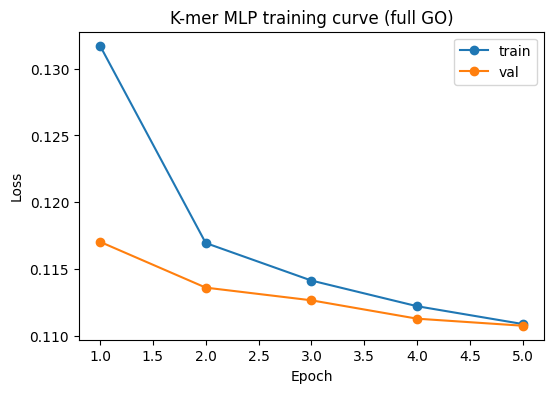

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label="train")
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("K-mer MLP training curve (full GO)")
plt.legend()
plt.show()

## Step 13. Reload the Best Model and Generate Validation Outputs

### Why this step?
Instead of evaluating the final epoch model, we reload the best checkpoint saved during training.  
This ensures that the threshold sweep is performed on the model that achieved the best validation loss.

### Why this matters
For fair model comparison later, we want evaluation to reflect the strongest saved version of the model, not just the latest one.

In [14]:
best_model = KmerMLP(
    input_dim=X_train.shape[1],
    output_dim=Y_train.shape[1]
).to(device)

best_model.load_state_dict(torch.load(save_path, map_location=device))

val_probs, val_targets = get_predictions(best_model, val_loader, device)

print("val_probs shape:", val_probs.shape)
print("val_targets shape:", val_targets.shape)

val_probs shape: (28114, 31454)
val_targets shape: (28114, 31454)


## Step 14. Run Threshold Sweep and Identify Best Validation Thresholds

### Why this step?
This step translates validation probabilities into final binary predictions using multiple thresholds.

Rather than assuming one universal threshold in advance, we search over a range of values and record:
- the threshold that maximizes micro-F1
- the threshold that maximizes macro-F1

### Why compare both
- **Best micro-F1** shows overall large-scale prediction quality
- **Best macro-F1** highlights how the model behaves on rare terms

In a long-tail problem like GO prediction, these two thresholds may not be the same.

In [15]:
thresholds = np.arange(0.05, 0.55, 0.05)
records, best_micro_row, best_macro_row = threshold_sweep(val_targets, val_probs, thresholds)

print("\nBest by micro-F1:", best_micro_row)
print("Best by macro-F1:", best_macro_row)

t=0.05 | micro-F1=0.0169 | macro-F1=0.0049
t=0.10 | micro-F1=0.0271 | macro-F1=0.0059
t=0.15 | micro-F1=0.0360 | macro-F1=0.0070
t=0.20 | micro-F1=0.0447 | macro-F1=0.0079
t=0.25 | micro-F1=0.0534 | macro-F1=0.0085
t=0.30 | micro-F1=0.0625 | macro-F1=0.0093
t=0.35 | micro-F1=0.0720 | macro-F1=0.0099
t=0.40 | micro-F1=0.0820 | macro-F1=0.0101
t=0.45 | micro-F1=0.0923 | macro-F1=0.0104
t=0.50 | micro-F1=0.1019 | macro-F1=0.0107

Best by micro-F1: {'threshold': 0.5, 'micro_f1': 0.10188075820385685, 'macro_f1': 0.010741589302462785}
Best by macro-F1: {'threshold': 0.5, 'micro_f1': 0.10188075820385685, 'macro_f1': 0.010741589302462785}


## Step 15. Save Training Results and Evaluation Summary

### Why this step?
Saving outputs to disk makes the experiment reproducible and easier to compare against future models such as:
- ESM-MLP
- namespace-specific models
- filtered-label variants
- structure-based graph models

### What we save
We store:
- model name
- input and output dimensions
- batch size and epoch count
- best validation loss
- best threshold-based F1 results
- training and validation loss history

### Why this is useful
This creates a lightweight experiment record that can be reused in reports, slides, or comparison tables later.

In [16]:
results = {
    "model": "kmer_mlp_full_go",
    "input_dim": int(X_train.shape[1]),
    "output_dim": int(Y_train.shape[1]),
    "batch_size": batch_size,
    "num_epochs": num_epochs,
    "best_val_loss": float(best_val_loss),
    "best_micro": best_micro_row,
    "best_macro": best_macro_row,
    "train_losses": train_losses,
    "val_losses": val_losses,
}

with open("kmer_mlp_full_go_metrics.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved metrics to kmer_mlp_full_go_metrics.json")

Saved metrics to kmer_mlp_full_go_metrics.json


In [17]:
import pandas as pd

df_thresh = pd.DataFrame(records)
display(df_thresh)

,threshold,micro_f1,macro_f1
0,0.05,0.016866,0.004892
1,0.10,0.027084,0.005940
2,0.15,0.036039,0.006956
3,0.20,0.044662,0.007884
4,0.25,0.053375,0.008542
5,0.30,0.062454,0.009281
6,0.35,0.072045,0.009851
7,0.40,0.082042,0.010145
8,0.45,0.092255,0.010445
9,0.50,0.101881,0.010742


## Step 16. Visualize Micro-F1 and Macro-F1 Across Thresholds

### Why this step?
A plot provides a more intuitive view of threshold sensitivity than a table alone.

### What this figure helps us see
- where micro-F1 peaks
- where macro-F1 peaks
- whether the model is robust to small threshold changes
- whether optimizing for global performance differs from optimizing for rare-label balance

### Interpretation note
For full-label GO prediction, it is common for macro-F1 to remain much lower than micro-F1 because many GO terms are extremely rare. This reflects the long-tail label distribution observed during preprocessing. :contentReference[oaicite:5]{index=5}

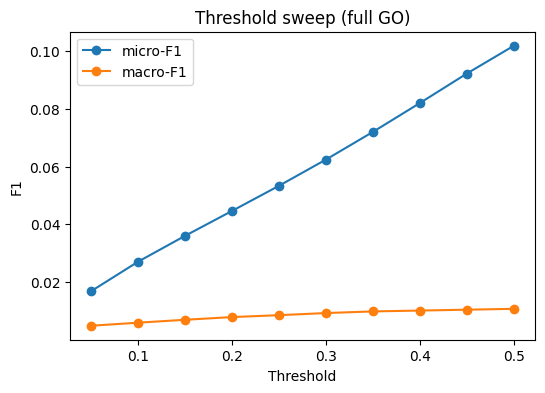

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(df_thresh["threshold"], df_thresh["micro_f1"], marker='o', label="micro-F1")
plt.plot(df_thresh["threshold"], df_thresh["macro_f1"], marker='o', label="macro-F1")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("Threshold sweep (full GO)")
plt.legend()
plt.show()